# Data Loading and Database Build

Load one subject from NinaPro DB1 to understand the .mat structure, then build a Python-friendly DB dictionary for all subjects and save it for reuse in later notebooks.


## What you will do
- Locate one subject .mat file.
- Inspect available variables and their shapes.
- Verify label conventions (`restimulus`, `rerepetition`).
- Plot a short sEMG segment with labels.
- Build a DB1 A1 dictionary and save it to a pickle for later notebooks.


## Data location and naming
We assume the preprocessed DB1 files are stored in:
`data/raw/DB1/sX/SX_A1_EY.mat`

Where:
- `sX` is the subject folder (e.g., `s1`).
- `A1` indicates the acquisition setup.
- `EY` is the exercise index (E1, E2, E3).

The tutorial uses sEMG only. The files also include CyberGlove signals,
but we do not use them in this pipeline.


If the file does not exist, run the download helper from Notebook 00 or via the CLI:
`python scripts/download_data.py --db 1 --start 1 --end 27 --workers 4`


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.io import build_db1_a1_database, save_db_pickle

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

DATA_ROOT = Path("../data/raw/DB1")
ACQ_SETUP = "A1"
SUBJECT_ID = 1
EXERCISE_ID = 1
FS = 100.0  # Hz

mat_path = DATA_ROOT / f"s{SUBJECT_ID}/S{SUBJECT_ID}_A1_E{EXERCISE_ID}.mat"
if not mat_path.exists():
    raise FileNotFoundError(
        f"Missing file: {mat_path}. Download DB1 data first."
    )

mat_path


PosixPath('../data/raw/DB1/s1/S1_A1_E1.mat')

In [2]:
mat_data = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
keys = [k for k in mat_data.keys() if not k.startswith("__")]

print("Keys in file:")
for key in keys:
    print(f"- {key}")


Keys in file:
- emg
- stimulus
- glove
- subject
- exercise
- repetition
- restimulus
- rerepetition


In [3]:
subject = int(np.atleast_1d(mat_data["subject"])[0])
exercise = int(np.atleast_1d(mat_data["exercise"])[0])
emg = np.asarray(mat_data["emg"])
glove = np.asarray(mat_data["glove"])
stimulus = np.asarray(mat_data["stimulus"])
restimulus = np.asarray(mat_data["restimulus"])
repetition = np.asarray(mat_data["repetition"])
rerepetition = np.asarray(mat_data["rerepetition"])

print(f"Subject: {subject} | Exercise: {exercise}")
print(f"EMG shape: {emg.shape} (samples x channels)")
print(f"Glove shape: {glove.shape} (samples x sensors)")
print(f"Duration: {emg.shape[0] / FS:.1f} s")
print(f"Labels: stimulus {stimulus.shape}, restimulus {restimulus.shape}")
print(f"Repetitions: repetition {repetition.shape}, rerepetition {rerepetition.shape}")


Subject: 1 | Exercise: 1
EMG shape: (101014, 10) (samples x channels)
Glove shape: (101014, 22) (samples x sensors)
Duration: 1010.1 s
Labels: stimulus (101014,), restimulus (101014,)
Repetitions: repetition (101014,), rerepetition (101014,)


In [4]:
np.unique(restimulus)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=uint8)

In [5]:
# Quick check across the three exercises for Subject 1
exercise_summary = []
for ex_id in [1, 2, 3]:
    ex_path = DATA_ROOT / f"s{SUBJECT_ID}/S{SUBJECT_ID}_A1_E{ex_id}.mat"
    ex_data = loadmat(ex_path, squeeze_me=True, struct_as_record=False)
    emg_ex = np.asarray(ex_data["emg"])
    restimulus_ex = np.asarray(ex_data["restimulus"]).astype(int)

    exercise_summary.append({
        "exercise": ex_id,
        "samples": emg_ex.shape[0],
        "duration_s": round(emg_ex.shape[0] / FS, 1),
        "emg_channels": emg_ex.shape[1],
        "movements": len(np.unique(restimulus_ex)) - 1,
    })

pd.DataFrame(exercise_summary)


,exercise,samples,duration_s,emg_channels,movements
0,1,101014,1010.1,10,12
1,2,142976,1429.8,10,17
2,3,227493,2274.9,10,23


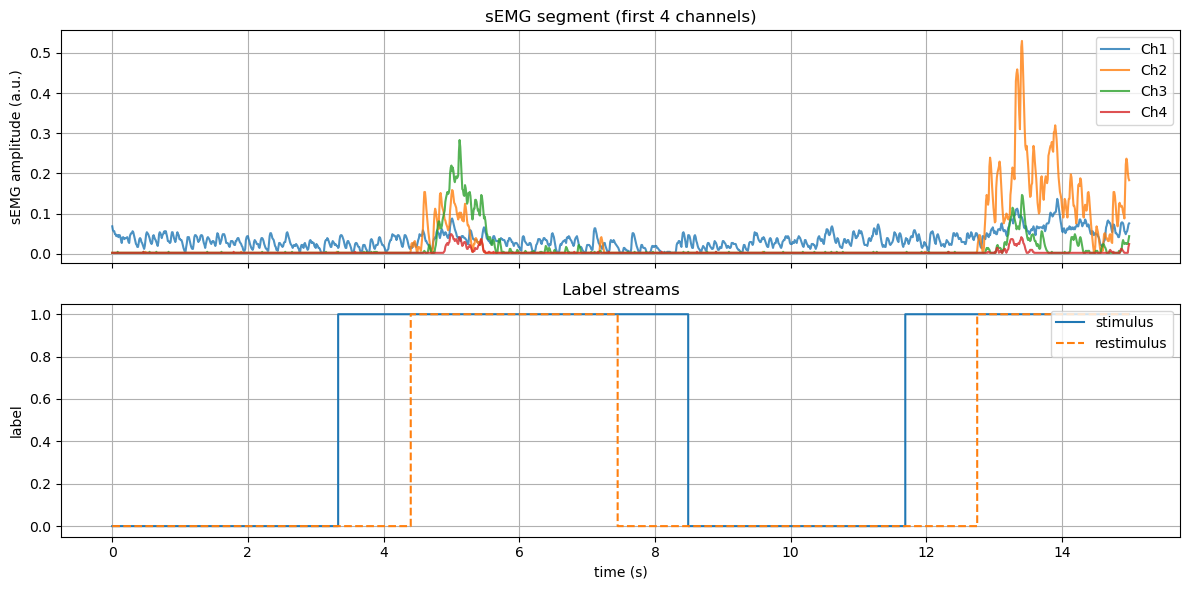

In [6]:
# Plot a short sEMG segment with labels
time_window_s = 15
n_samples = int(time_window_s * FS)
time_axis = np.arange(n_samples) / FS

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# sEMG channels (first 4)
for ch in range(min(4, emg.shape[1])):
    axes[0].plot(time_axis, emg[:n_samples, ch], label=f"Ch{ch+1}", alpha=0.8)
axes[0].set_ylabel("sEMG amplitude (a.u.)")
axes[0].set_title("sEMG segment (first 4 channels)")
axes[0].legend(loc="upper right")

# Labels (stimulus vs restimulus)
axes[1].plot(time_axis, stimulus[:n_samples], drawstyle="steps-post", label="stimulus")
axes[1].plot(time_axis, restimulus[:n_samples], drawstyle="steps-post", label="restimulus", linestyle="--")
axes[1].set_ylabel("label")
axes[1].set_xlabel("time (s)")
axes[1].set_title("Label streams")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


## Build a DB dictionary (all subjects)

We organize DB1 A1 into a nested dictionary and reuse helper functions from `src/io.py`.
We save the dictionary to disk as a pickle for later notebooks.

```python
db = {
  subject_id: {
    "meta": {"subject_id": int},
    "exercises": {
      exercise_id: {
        "emg": np.ndarray[T, n_emg],
        "glove": np.ndarray[T, n_glove],
        "stimulus": np.ndarray[T],
        "restimulus": np.ndarray[T],
        "repetition": np.ndarray[T],
        "rerepetition": np.ndarray[T],
        "path": Path,
      }
    }
  }
}
```


In [7]:
db = build_db1_a1_database(DATA_ROOT, ACQ_SETUP)
print(f"Loaded subjects: {sorted(db.keys())}")

OUT_PATH = Path("../data/processed/db1_a1.pkl")
save_db_pickle(db, OUT_PATH)
OUT_PATH


Loaded subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


PosixPath('../data/processed/db1_a1.pkl')

## Next step
Proceed to exploratory data analysis to study Subject 01 sEMG characteristics and overall variability across subjects and movements.
